In [1]:
from spiderstate.cat_at_origin import *
from spidercat.draw import draw_forest_on_graph

%load_ext autoreload
%autoreload 2

R 0 1 2
RX 3 4 5
R 6
CX 5 1 5 2 3 1 4 2 3 6 4 6


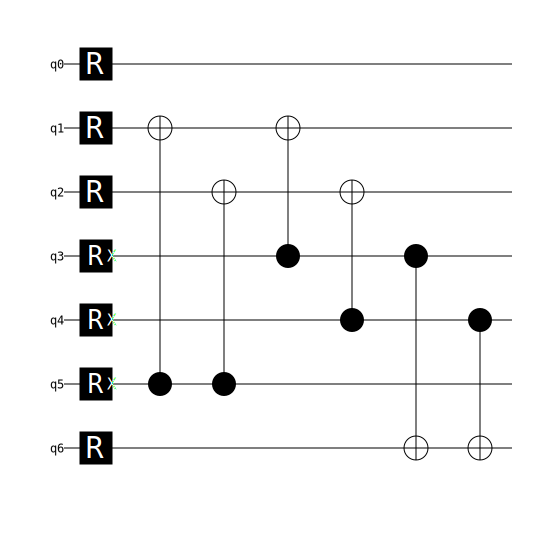

In [7]:
H_x, d = np.array([
  [0, 1, 1, 0, 0, 1, 0, ],
  [0, 1, 0, 1, 0, 0, 1, ],
  [0, 0, 1, 0, 1, 0, 1, ],
]), 3
# H_x, d = np.array([
#   [1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1],
#   [0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1],
#   [0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1],
#   [0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1]
# ]), 3
# H_x, d = np.array([
#     [0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
#     [1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
#     [0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
#     [1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
#     [1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
#     [1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
#     [0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
#     [0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
#     [0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
#     [1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
#     [1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
# ]), 7


circ = cat_at_origin(H_x, d)
circ.diagram('timeline-svg')
print(circ)

In [161]:
circuit = circ.copy()
circuit.append("M", range(H_x.shape[1]))
samples = circuit.compile_sampler().sample(10)
meas_samples = samples[:,-H_x.shape[1]:]
print(meas_samples @ H_x.T % 2)

[[0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]]


In [162]:
from spidercat.simulate import _layer_cnot_circuit

raw_cnots = [l for (name, l, _) in circ.flattened_operations() if name == "CX"]
cnots = [(ops[i], ops[i + 1]) for ops in raw_cnots for i in range(0, len(ops), 2)]
print("Num CX:", len(cnots))
print("Num Flags:", circ.num_qubits - H_x.shape[1])
print("Num qubits:", circ.num_qubits)
layered_cnots = _layer_cnot_circuit(cnots)
print("Depth:", len(layered_cnots))

Num CX: 17
Num Flags: 4
Num qubits: 11
Depth: 5
